# Spaceship Titanic

## 1. Постановка задачи


Необходимо предсказать, был ли пассажир перенесён в другое измерение во время столкновения корабля с космической аномалией.

- Тип задачи: бинарная классификация.
- Датасет: Spaceship Titanic.
- Целевая переменная: `Transported`.
- Метрика соревнования: Accuracy.

В работе выполняются исследовательский анализ данных, создание новых признаков, сравнение моделей, подбор гиперпараметров LightGBM, stacking и подготовка submission для Kaggle.

# 2. Загрузка данных и первичный анализ

In [1]:
import math
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import clone


RANDOM_STATE = 42 

In [2]:
train = pd.read_csv('data/train.csv')
test =  pd.read_csv('data/test.csv')

In [3]:
print(f'Train выборка содержит {train.shape[0]} строк и {train.shape[1]} столбцов' )
print(f'Test выборка содержит {test.shape[0]} строк и {test.shape[1]} столбцов' )

Train выборка содержит 8693 строк и 14 столбцов
Test выборка содержит 4277 строк и 13 столбцов


In [4]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [5]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
test_columns = test.columns.to_list()
train_columns = train.columns.to_list()
print(f'Колонки в тестовой выборке: \n{test_columns}')
print(f'Колонки в train выборке: \n{train_columns}')

Колонки в тестовой выборке: 
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']
Колонки в train выборке: 
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']


Единственное отличие train и test — наличие целевой переменной `Transported` в train. Наборы исходных признаков согласованы, поэтому тестовую выборку можно подготовить той же функцией feature engineering и передать в финальную модель.

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


По описательной статистике видно, что более половины пассажиров не тратили деньги на отдельные услуги на борту. На этапе feature engineering будет создан бинарный признак `HasSpending`, который отделит пассажиров без расходов от остальных.


# 3. EDA 

## Баланс целевой переменной

Сначала оценим количество пассажиров в каждом классе `Transported` и их доли в обучающей выборке. Это позволит понять, есть ли дисбаланс классов, который может повлиять на обучение модели.

In [9]:
print(train.Transported.value_counts())
print(train.Transported.value_counts(normalize=True))

Transported
True     4378
False    4315
Name: count, dtype: int64
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


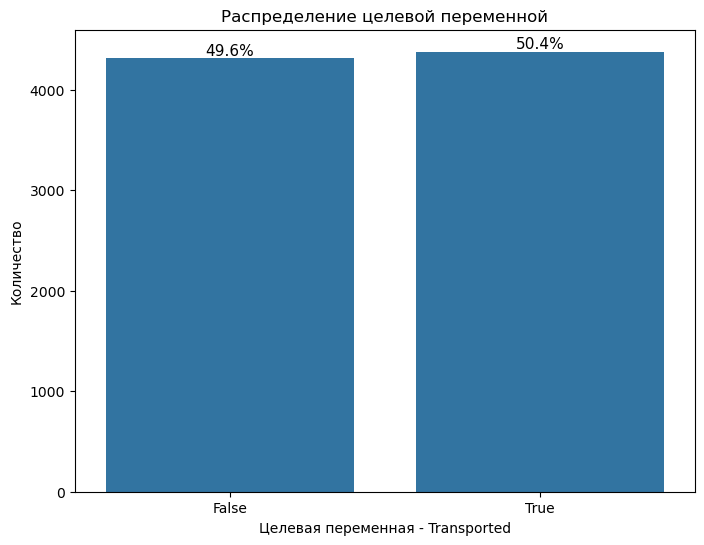

In [10]:
plt.figure(figsize=(8,6))

ax = sns.countplot(data=train, x='Transported')

total = len(train)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=11
    )

plt.xlabel('Целевая переменная - Transported')
plt.ylabel('Количество')
plt.title('Распределение целевой переменной')
plt.show()

Целевая переменная распределена практически равномерно: доли классов отличаются только на 0,8 п.п. Следовательно, применять специальные методы балансировки классов не требуется.

## Пропуски и дубликаты

Проверим количество пропусков в признаках и наличие полных дубликатов строк. Это нужно для выбора стратегии очистки данных.

In [11]:
missing_values = train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=True)
missing_values_percent = (missing_values/len(train)) * 100

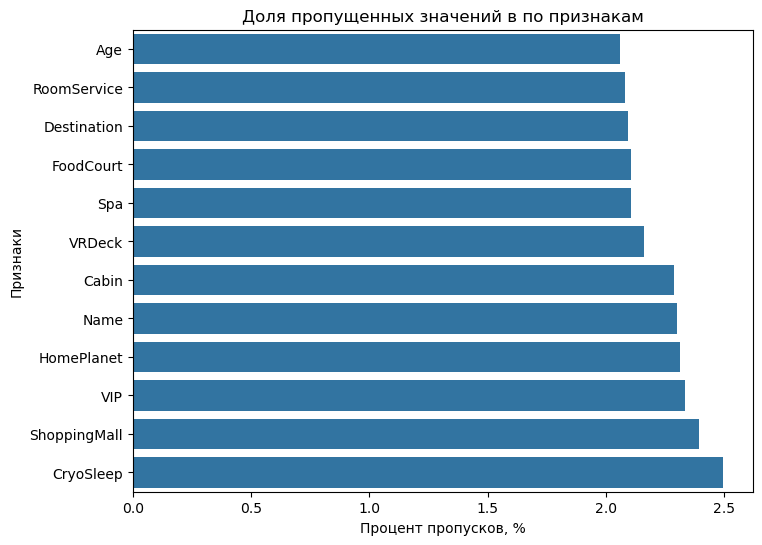

In [12]:
plt.figure(figsize = (8,6))

ax = sns.barplot(x = missing_values_percent.values, y = missing_values_percent.index)
plt.xlabel('Процент пропусков, %')
plt.ylabel('Признаки')
plt.title('Доля пропущенных значений в по признакам')
plt.show()

Пропуски присутствуют в 12 из 14 признаков, но их доля в каждом случае не превышает 3 %. Удаление строк привело бы к неоправданной потере данных, поэтому категориальные пропуски будут заполнены модой, а числовые — медианой.

Проверим обучающую выборку на полные дубликаты, чтобы избежать повторного учёта одинаковых наблюдений при обучении модели.

In [13]:
print(train.duplicated().sum())
print(test.duplicated().sum())


0
0


Полные дубликаты в обучающей выборке отсутствуют, поэтому дополнительная обработка дубликатов не требуется.

## Категориальные признаки

Рассмотрим распределения категориальных признаков и их связь с целевой переменной `Transported`. Это поможет определить признаки, которые могут быть полезны модели.

In [14]:
categorical_columns = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
]
for column in categorical_columns:
    print(f'\nПризнак {column} :' )
    print(train[column].value_counts())


Признак HomePlanet :
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

Признак CryoSleep :
CryoSleep
False    5439
True     3037
Name: count, dtype: int64

Признак Destination :
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

Признак VIP :
VIP
False    8291
True      199
Name: count, dtype: int64


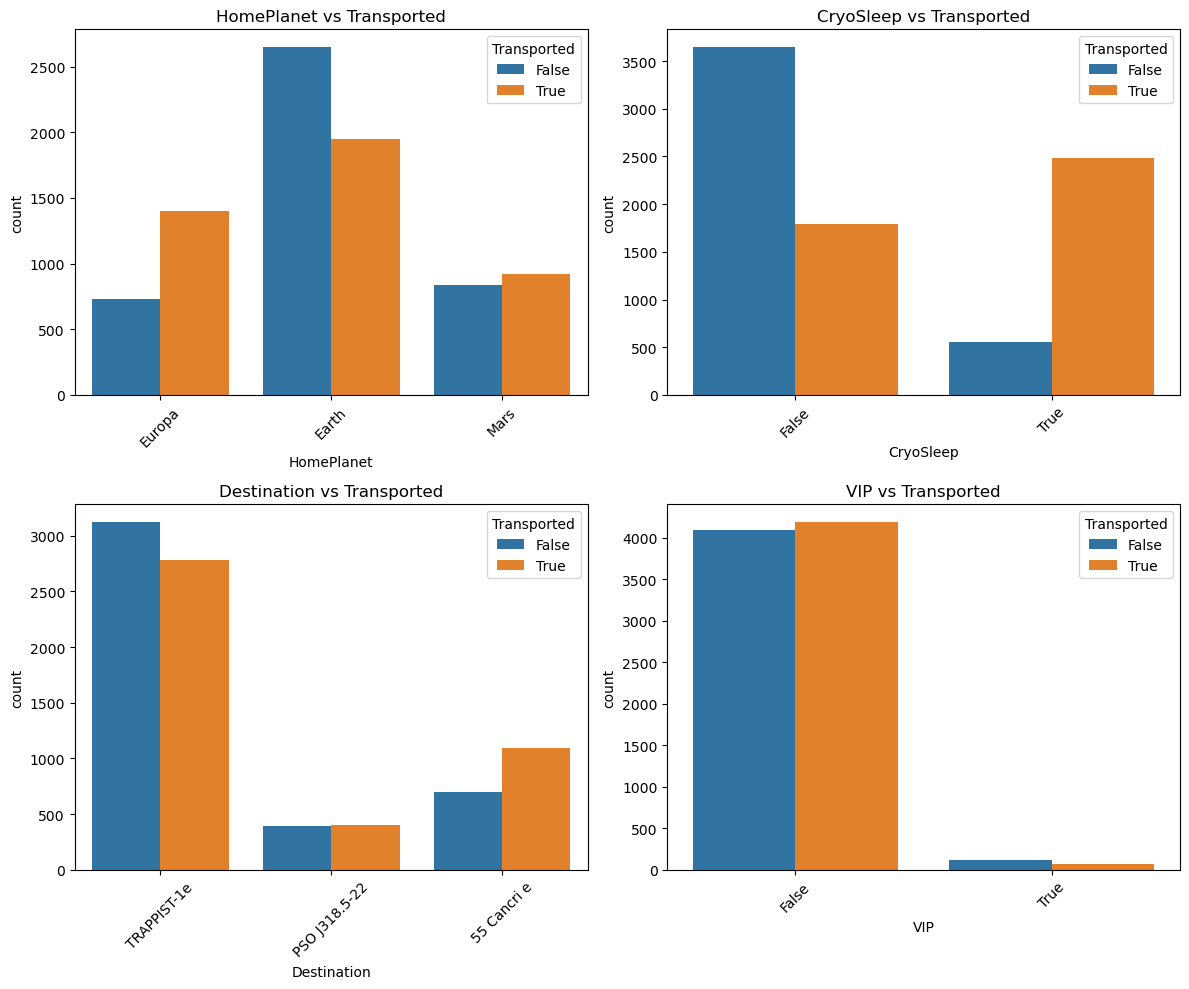

In [15]:
n_cols = 2
n_rows = -(-len(categorical_columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    sns.countplot(data=train, x=column, hue='Transported', ax=axes[i])
    axes[i].set_title(f'{column} vs Transported')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Наиболее заметная зависимость наблюдается для признака `CryoSleep`: среди пассажиров в криосне больше тех, кто был перемещён. Для остальных категориальных признаков явных различий между классами не видно, однако их всё равно сохраним для модели.

## Числовые признаки

Проанализируем распределения возраста и расходов на услуги корабля в разрезе целевой переменной. Это позволит выявить различия между классами и особенности распределений.

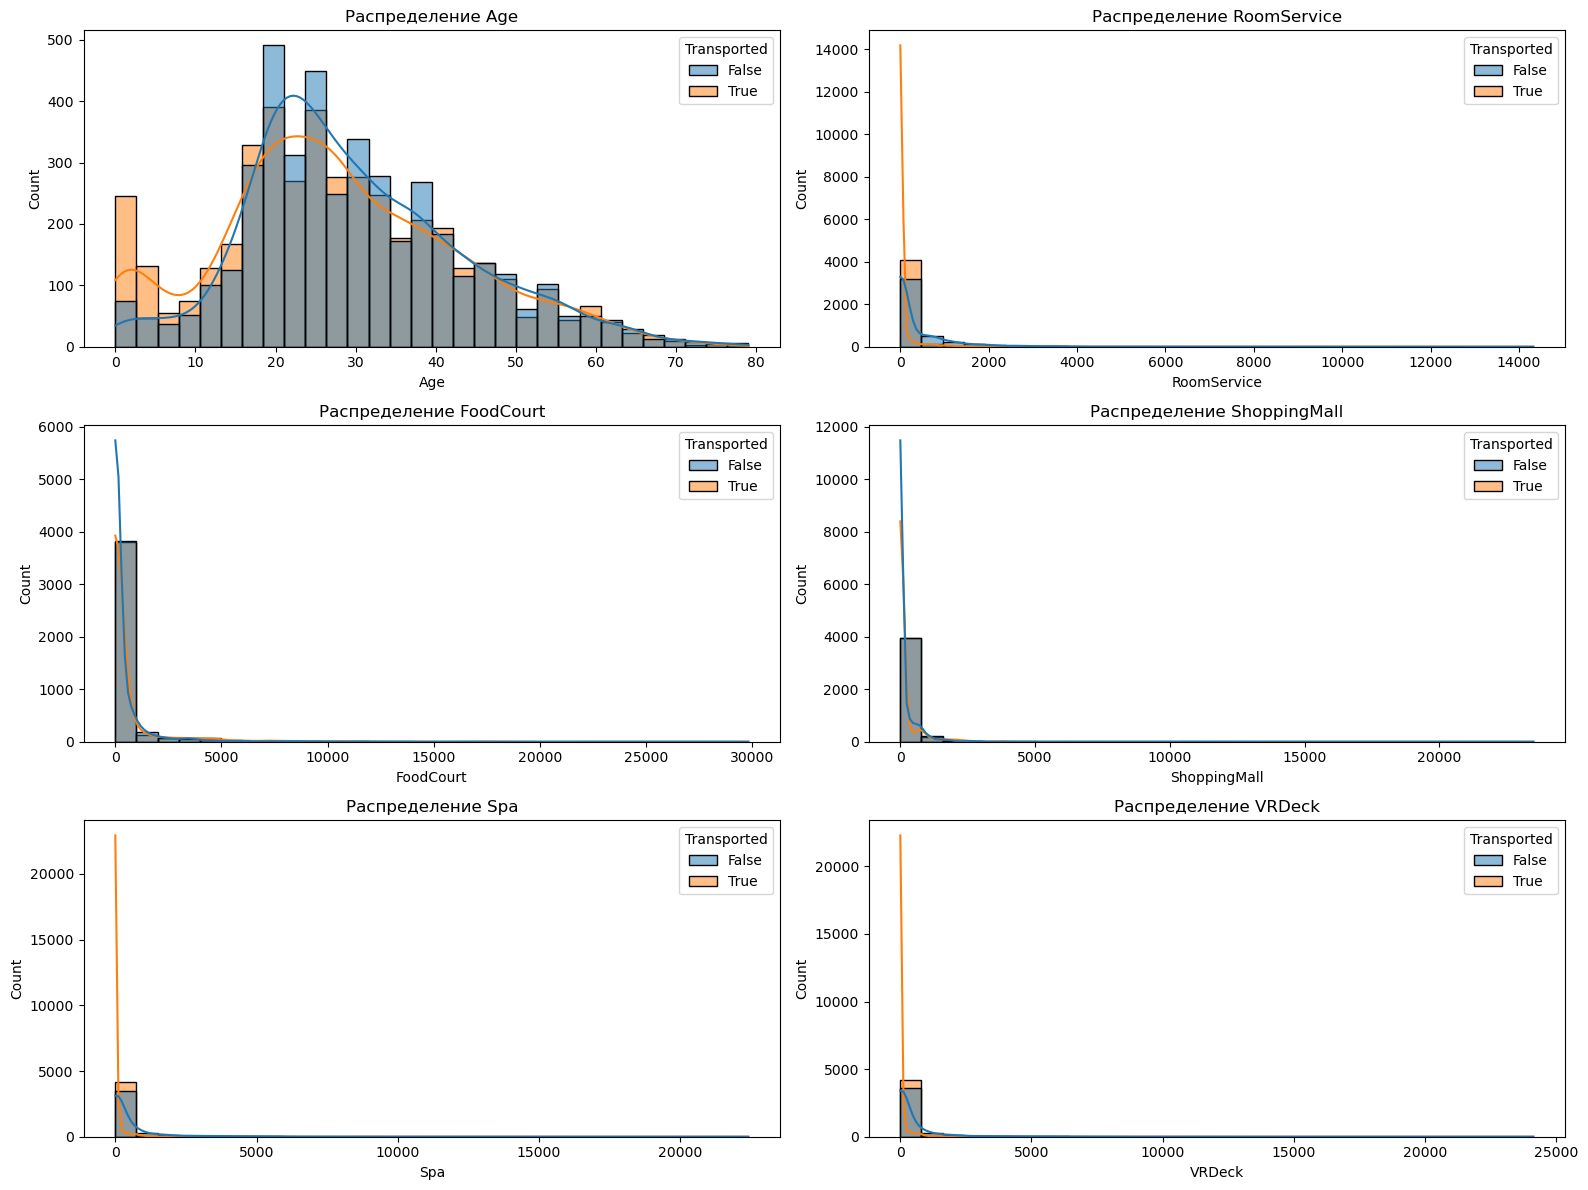

In [16]:
numeric_columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

n_cols = 2
n_rows = -(-len(numeric_columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=train, x=column, hue='Transported', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Распределение {column}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Дети заметно чаще оказывались перемещёнными, поэтому на этапе feature engineering будет создан признак `IsChild`. Расходы на услуги имеют сильно скошенные вправо распределения; преобразование `log(1 + x)` используется на графиках для более наглядного анализа, а в модели сохраняются исходные значения расходов.

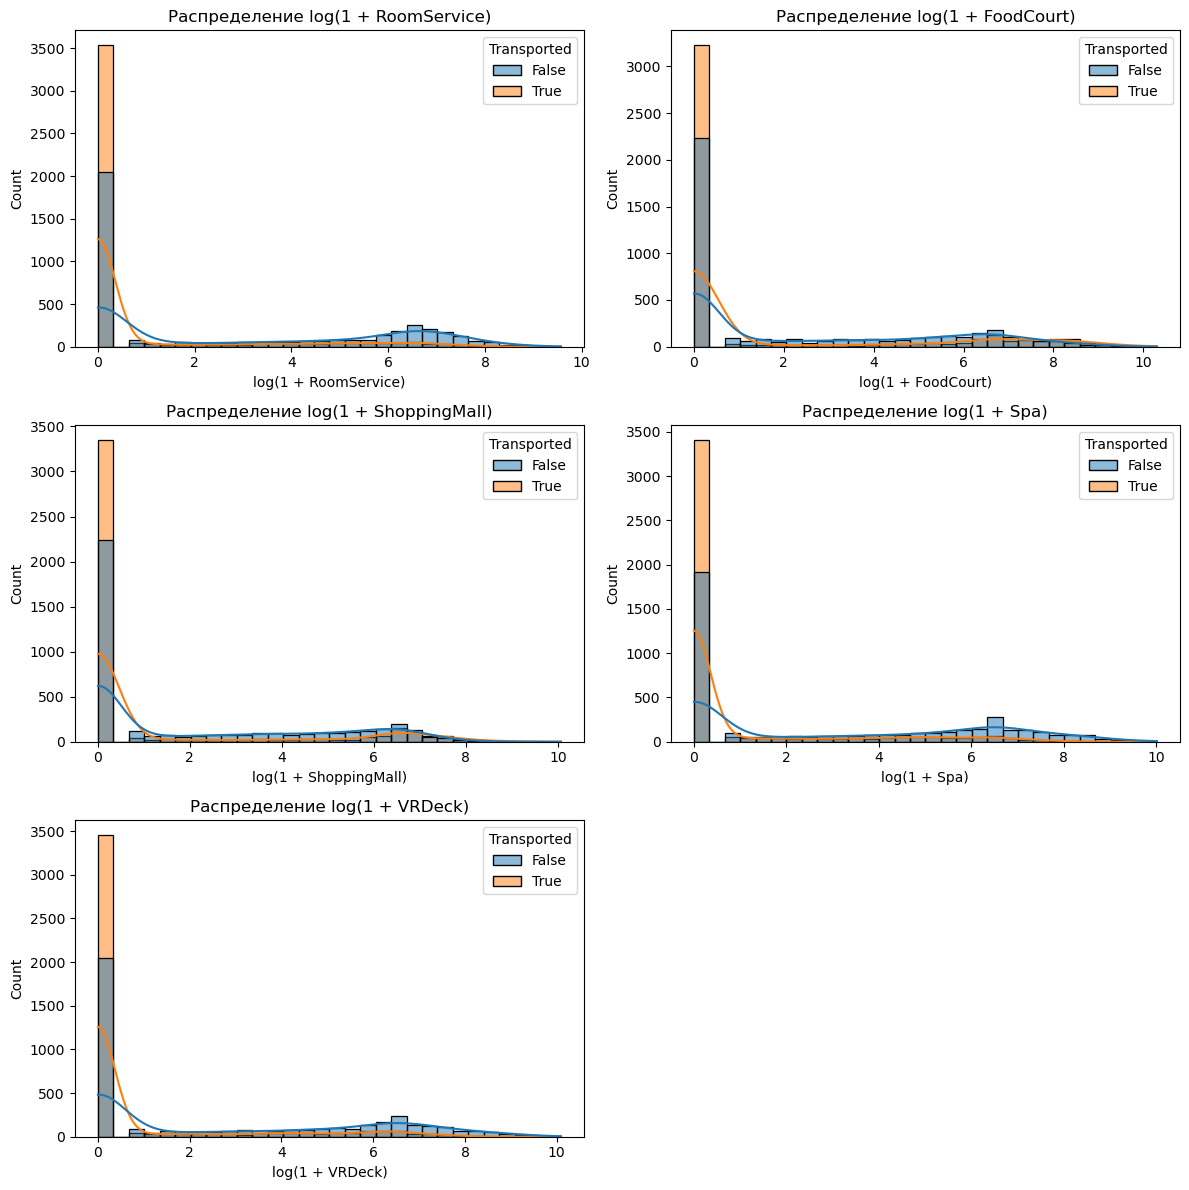

In [17]:
spending_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

n_cols = 2
n_rows = -(-len(numeric_columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, spending_columns):
    sns.histplot(x=np.log1p(train[column]), hue=train['Transported'], kde=True, ax=ax, bins=30)
    ax.set_title(f'Распределение log(1 + {column})')
    ax.set_xlabel(f'log(1 + {column})')

for ax in axes[len(spending_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Корреляции числовых признаков

В завершение оценим корреляции числовых признаков. Это позволит выявить возможные линейные зависимости между расходами и возрастом и учесть их при подготовке данных.

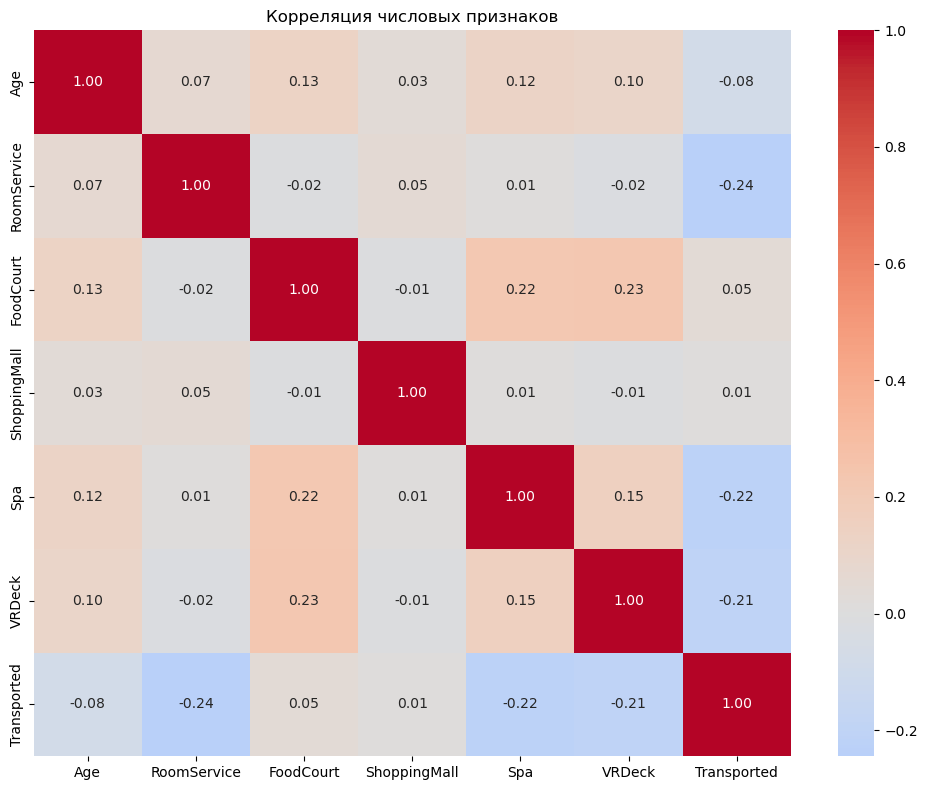

In [18]:
plt.figure(figsize=(10,8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

### Вывод по EDA

Датасет Spaceship Titanic содержит 8 693 объекта в обучающей выборке и 4 277 объектов в тестовой. Целевая переменная - `Transported`; классы практически сбалансированы: 50.4% пассажиров были перемещены и 49.6% - нет. Поэтому специальные методы балансировки классов не требуются, а основной метрикой качества будет `Accuracy`.

В данных присутствуют пропуски в 12 признаках, однако их доля в каждом случае не превышает 2.5%. Удаление строк приведёт к ненужной потере данных, поэтому в дальнейшем числовые признаки будут заполняться медианой, а категориальные - наиболее частым значением. Полных дубликатов в train и test не обнаружено.

Среди категориальных признаков наиболее сильная связь с целевой переменной наблюдается у `CryoSleep`: пассажиры в криосне значительно чаще оказывались перемещёнными. Также полезный сигнал дают `HomePlanet` и `Destination`, поэтому эти признаки будут сохранены и закодированы для моделей.

Числовые признаки расходов имеют сильно скошенные распределения вправо: более чем у половины пассажиров расходы по отдельным услугам равны нулю, но встречаются редкие крупные траты.

Возраст также связан с целевой переменной: дети чаще оказывались перемещёнными, поэтому был создан признак `IsChild`. Корреляционная матрица не показывает критической линейной зависимости между числовыми признаками, однако расходы и возраст будут использоваться вместе с новыми агрегированными признаками.



# 4. Feature Engineering
Создадим признаки из идентификатора пассажира, каюты, расходов, возраста и количества пропусков. Полезность этих признаков позже проверим сравнением качества моделей на кросс-валидации.

In [19]:
def add_features(df):
    df = df.copy()

    source_columns = [
        column for column in df.columns
        if column != 'Transported'
    ]
    df['MissingCount'] = df[source_columns].isna().sum(axis=1)

    passenger_parts = df['PassengerId'].str.split('_', expand=True)
    df['GroupId'] = passenger_parts[0]
    df['GroupMemberNumber'] = pd.to_numeric(
        passenger_parts[1],
        errors='coerce'
    )

    group_sizes = df['GroupId'].value_counts()
    df['GroupSize'] = df['GroupId'].map(group_sizes)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

    cabin_parts = df['Cabin'].str.split('/', expand=True)
    df['CabinDeck'] = cabin_parts[0]
    df['CabinNumber'] = pd.to_numeric(
        cabin_parts[1],
        errors='coerce'
    )
    df['CabinSide'] = cabin_parts[2]

    spending_columns = [
        'RoomService',
        'FoodCourt',
        'ShoppingMall',
        'Spa',
        'VRDeck'
    ]
    df['TotalSpend'] = df[spending_columns].sum(axis=1, min_count=1)
    df['HasSpending'] = np.where(
        df['TotalSpend'].isna(),
        np.nan,
        (df['TotalSpend'] > 0).astype(int)
    )

    df['IsChild'] = np.where(
        df['Age'].isna(),
        np.nan,
        (df['Age'] < 13).astype(int)
    )

    return df


train_fe = add_features(train)
test_fe = add_features(test)

print('Train после feature engineering:', train_fe.shape)
print('Test после feature engineering:', test_fe.shape)
train_fe.head()

Train после feature engineering: (8693, 25)
Test после feature engineering: (4277, 24)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,GroupId,GroupMemberNumber,GroupSize,IsAlone,CabinDeck,CabinNumber,CabinSide,TotalSpend,HasSpending,IsChild
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0001,1,1,1,B,0.0,P,0.0,0.0,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,0002,1,1,1,F,0.0,S,736.0,1.0,0.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,0003,1,2,0,A,0.0,S,10383.0,1.0,0.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,0003,2,2,0,A,0.0,S,5176.0,1.0,0.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,0004,1,1,1,F,1.0,S,1091.0,1.0,0.0


### Проверка созданных признаков
Посмотрим на первые строки новых признаков и затем оценим их связь с целевой переменной.

In [20]:
def show_target_rate(df, column):
    result = (
        df.groupby(
            column,
            dropna=False,
            observed=False
        )["Transported"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    result["mean"] = result["mean"].round(4)

    return result


for column in ['HasSpending', 'IsAlone', 'CabinDeck', 'CabinSide', 'IsChild']:
    print(f'\n{column}:')
    display(show_target_rate(train_fe, column))


HasSpending:


,count,mean
HasSpending,,
0.0,3653,0.7865
1.0,5040,0.2986



IsAlone:


,count,mean
IsAlone,,
0,3888,0.5669
1,4805,0.4524



CabinDeck:


,count,mean
CabinDeck,,
B,779,0.7343
C,747,0.6801
G,2559,0.5162
NaN,199,0.5025
A,256,0.4961
F,2794,0.4399
D,478,0.4331
E,876,0.3573
T,5,0.2000



CabinSide:


,count,mean
CabinSide,,
S,4288,0.5550
NaN,199,0.5025
P,4206,0.4513



IsChild:


,count,mean
IsChild,,
1.0,806,0.6998
NaN,179,0.5028
0.0,7708,0.4831


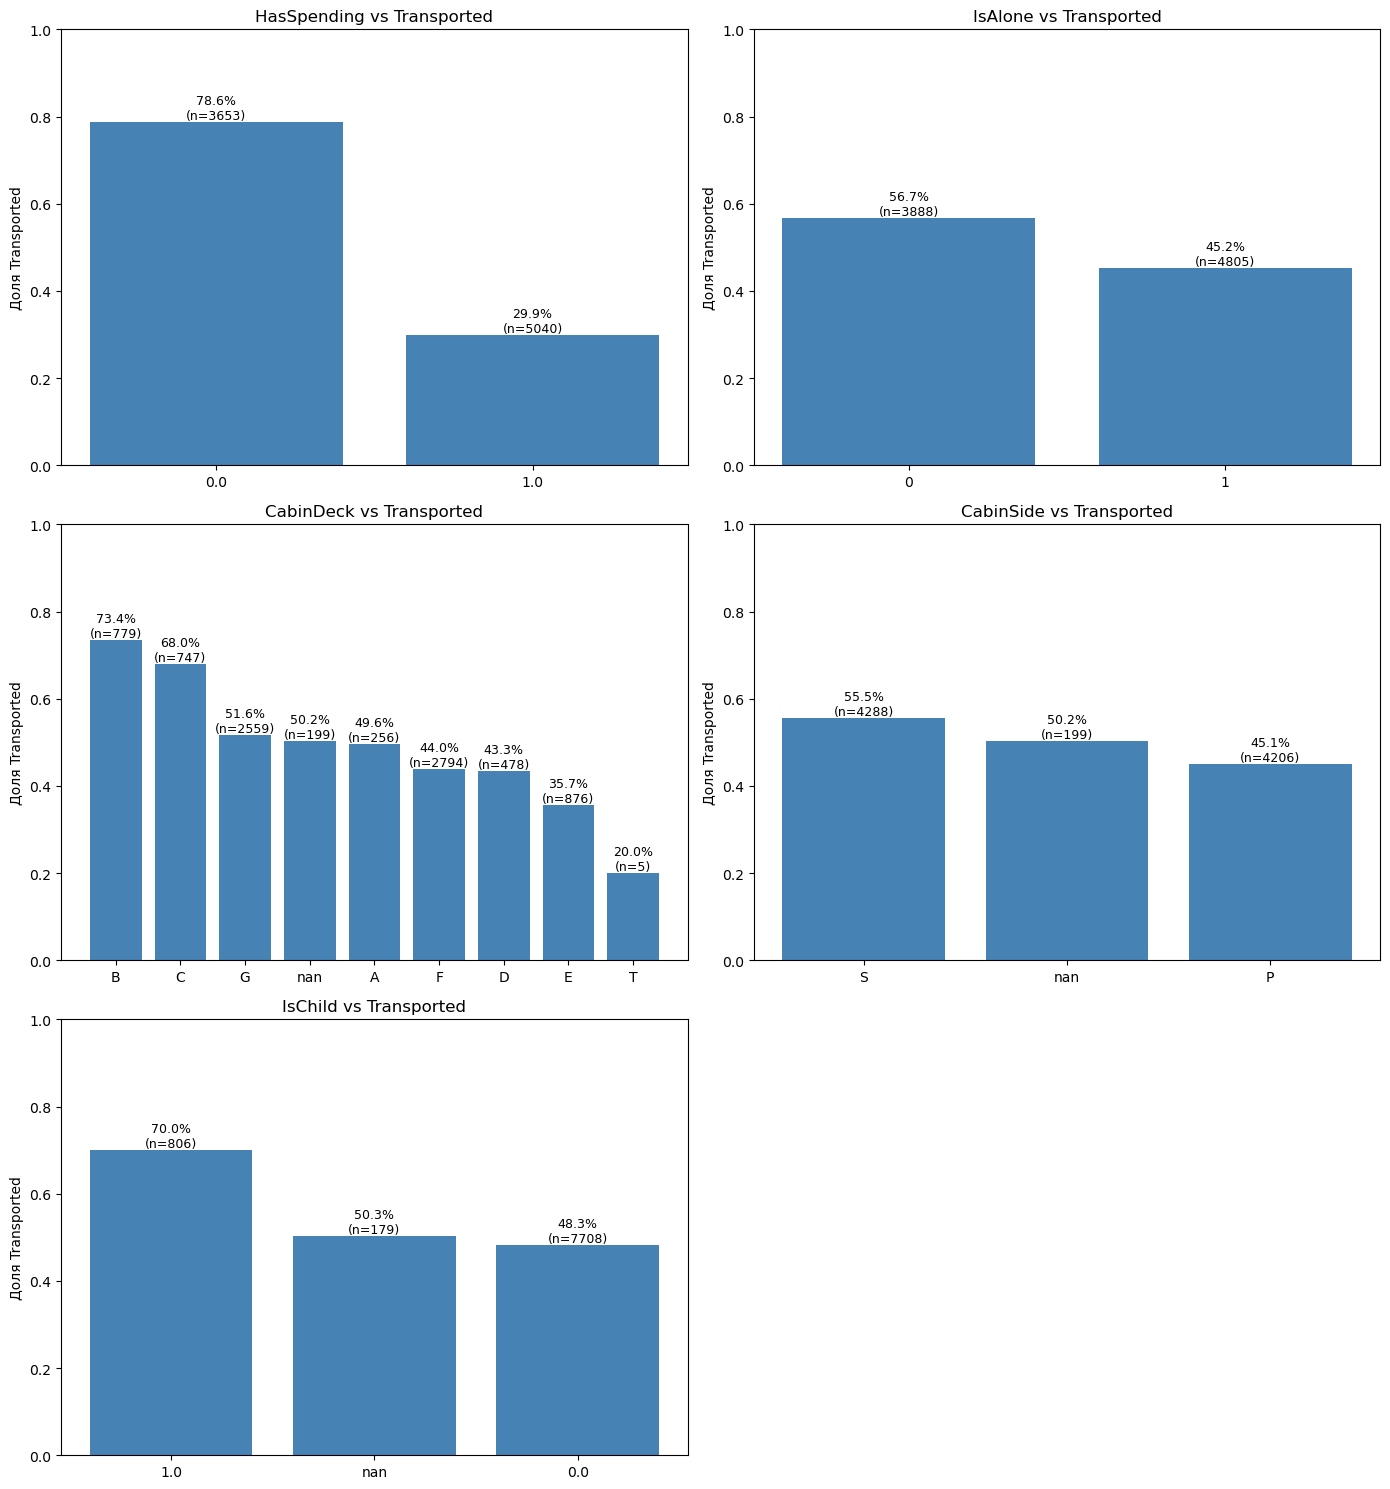

In [21]:
features_to_plot = ['HasSpending', 'IsAlone', 'CabinDeck', 'CabinSide', 'IsChild']

n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, features_to_plot):
    summary = show_target_rate(train_fe, column)
    
    bars = ax.bar(summary.index.astype(str), summary['mean'], color='steelblue')
    
    for bar, count in zip(bars, summary['count']):
        height = bar.get_height()
        ax.annotate(
            f'{height:.1%}\n(n={count})',
            (bar.get_x() + bar.get_width() / 2, height),
            ha='center', va='bottom', fontsize=9
        )
    ax.set_title(f'{column} vs Transported')
    ax.set_ylabel('Доля Transported')
    ax.set_ylim(0, 1)

for ax in axes[len(features_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Вывод по созданным признакам

Из исходных данных были получены новые характеристики:

- размер группы, номер пассажира внутри группы и факт одиночного путешествия;
- палуба, номер и сторона каюты;
- суммарные расходы и факт наличия расходов;
- бинарный признак ребёнка (`IsChild`);
- количество пропусков в записи пассажира.

Наиболее выраженная зависимость с целевой переменной наблюдается у `HasSpending`: среди пассажиров без расходов доля перемещённых составляет 78.6%, тогда как среди пассажиров с расходами — 29.9%.

Также информативными выглядят `IsChild`, `IsAlone`, `CabinDeck` и `CabinSide`. Дети перемещались заметно чаще взрослых пассажиров (70.0% против 48.3%). Пассажиры, путешествующие в группе, чаще оказывались перемещёнными, чем путешествующие в одиночку. На палубах B и C доля перемещённых выше, чем на палубах E, F и D; на стороне S она выше, чем на стороне P.

Признаки `GroupMemberNumber`, `CabinNumber` и `MissingCount` также сохраняются для последующей проверки моделями. Их фактическую полезность оценим через изменение Accuracy на кросс-валидации.

# 5. Моделирование

Все модели сравниваются по Accuracy с использованием одной и той же стратифицированной пятикратной кросс-валидации. Предобработка данных выполняется внутри `Pipeline`, чтобы исключить утечку информации между фолдами.


## Baseline: Random Forest на исходных признаках

В качестве baseline используется Random Forest на исходных признаках. Из набора исключаются `PassengerId`, `Cabin` и `Name`, поскольку они требуют отдельного преобразования и не используются в этой первой версии модели.

Затем та же модель будет проверена на наборе после feature engineering. Это позволит измерить вклад созданных признаков.


In [22]:
baseline_rf_columns = [
 'HomePlanet',
 'CryoSleep',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
]


In [23]:
X_baseline_rf = train[baseline_rf_columns].copy()
y_baseline_rf = train['Transported'].astype(int)

In [24]:
categorical_features = X_baseline_rf.select_dtypes(include= 'object').columns.tolist()
numeric_features = X_baseline_rf.select_dtypes(include='float64').columns.tolist()
print(f'Категорильаные признаки: \n{categorical_features}')
print(f'Числовые признаки:\n{numeric_features}')

Категорильаные признаки: 
['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
Числовые признаки:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


In [25]:
print(f'Размеры X_baseline_rf : {X_baseline_rf.shape}')
print(f'Размеры y_baseline_rf : {y_baseline_rf.shape}')

print(f'Пропуски в X_baseline: \n{X_baseline_rf.isnull().sum()}')


Размеры X_baseline_rf : (8693, 10)
Размеры y_baseline_rf : (8693,)
Пропуски в X_baseline: 
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
dtype: int64


In [26]:
numeric_transformer_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])



categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])


preprocessor = ColumnTransformer([
    (
        'numeric', 
        numeric_transformer_rf,
        numeric_features
    
    ),
    (
        'categorical',
        categorical_transformer,
        categorical_features

        
    )
])


In [27]:
baseline_rf_model = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    
    (
        'model',
        RandomForestClassifier(random_state= RANDOM_STATE)
    )
])

In [28]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= RANDOM_STATE)

In [29]:
baseline_rf_scores = cross_val_score(
    estimator = baseline_rf_model,
    X = X_baseline_rf,
    y = y_baseline_rf, 
    cv = cv,
    scoring= 'accuracy'
) 

In [30]:
print(f'Accuracy по фолдам: {np.round(baseline_rf_scores, 4)}')

Accuracy по фолдам: [0.7901 0.7838 0.7855 0.7888 0.7762]


In [31]:
print(f'Accuracy по всей модели: {np.round(baseline_rf_scores, 4).mean()} ')

Accuracy по всей модели: 0.78488 


### Результат baseline Random Forest


Baseline Random Forest показал среднюю Accuracy `0.7849` на пяти фолдах. Этот результат используется как точка отсчёта для оценки вклада feature engineering.

## Random Forest после Feature Engineering

Модель использует набор признаков после feature engineering. Стратегия обработки пропусков и One-Hot Encoding остаются внутри общего `preprocessor_tree`; изменяется только набор входных признаков.


In [32]:
colums_to_drop = [
     "Transported",
    "PassengerId",
    "GroupId",
    "Cabin",
    "Name"
]

In [33]:
X_rf_fe = train_fe.drop(columns = colums_to_drop)

In [34]:
print(f'Размеры X_rf_fe : {X_rf_fe.shape}')
print(f'Размеры y_baseline_rf : {y_baseline_rf.shape}')

print(f'Пропуски в X_rf_fe: \n{X_rf_fe.isnull().sum()}')

Размеры X_rf_fe : (8693, 20)
Размеры y_baseline_rf : (8693,)
Пропуски в X_rf_fe: 
HomePlanet           201
CryoSleep            217
Destination          182
Age                  179
VIP                  203
RoomService          181
FoodCourt            183
ShoppingMall         208
Spa                  183
VRDeck               188
MissingCount           0
GroupMemberNumber      0
GroupSize              0
IsAlone                0
CabinDeck            199
CabinNumber          199
CabinSide            199
TotalSpend             0
HasSpending            0
IsChild              179
dtype: int64


In [35]:
X_rf_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HomePlanet         8492 non-null   object 
 1   CryoSleep          8476 non-null   object 
 2   Destination        8511 non-null   object 
 3   Age                8514 non-null   float64
 4   VIP                8490 non-null   object 
 5   RoomService        8512 non-null   float64
 6   FoodCourt          8510 non-null   float64
 7   ShoppingMall       8485 non-null   float64
 8   Spa                8510 non-null   float64
 9   VRDeck             8505 non-null   float64
 10  MissingCount       8693 non-null   int64  
 11  GroupMemberNumber  8693 non-null   int64  
 12  GroupSize          8693 non-null   int64  
 13  IsAlone            8693 non-null   int32  
 14  CabinDeck          8494 non-null   object 
 15  CabinNumber        8494 non-null   float64
 16  CabinSide          8494 

In [36]:
categorical_features_fe = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'CabinDeck',
    'CabinSide',
]

numeric_features_fe = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'GroupMemberNumber',
    'GroupSize',
    'IsAlone',
    'CabinNumber',
    'TotalSpend',
    'HasSpending',
    'IsChild',
    'MissingCount',
]

print(f'Категорильаные признаки: \n{categorical_features_fe}')
print(f'Числовые признаки:\n{numeric_features_fe}')

Категорильаные признаки: 
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']
Числовые признаки:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupMemberNumber', 'GroupSize', 'IsAlone', 'CabinNumber', 'TotalSpend', 'HasSpending', 'IsChild', 'MissingCount']


In [37]:
numeric_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])



categorical_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])


preprocessor_tree = ColumnTransformer([
    (
        'numeric', 
        numeric_transformer_tree,
        numeric_features_fe
    
    ),
    (
        'categorical',
        categorical_transformer_tree,
        categorical_features_fe

        
    )
])


In [38]:
rf_fe_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree
    ),
    
    (
        'model',
        RandomForestClassifier(random_state= RANDOM_STATE)
    )
])

In [39]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= RANDOM_STATE)

In [40]:
rf_fe_score = cross_val_score(
    estimator = rf_fe_model,
    X = X_rf_fe,
    y = y_baseline_rf, 
    cv = cv,
    scoring= 'accuracy'
) 

In [41]:
print(f'Accuracy по фолдам: {np.round(rf_fe_score, 4)}')
print(f'Среднее Accuracy по всей модели: {rf_fe_score.mean():.4f}')
print(f'Стандартное отклонение: {rf_fe_score.std():.4f}')
print(f'Разница со baseline: {rf_fe_score.mean() - baseline_rf_scores.mean():.4f}')

Accuracy по фолдам: [0.812  0.7913 0.8068 0.8044 0.7871]
Среднее Accuracy по всей модели: 0.8003
Стандартное отклонение: 0.0095
Разница со baseline: 0.0154


### Результат Random Forest после Feature Engineering

Средняя Accuracy выросла с `0.7849` до `0.8003`, то есть на `0.0154`. Новые признаки заметно улучшают качество Random Forest, поэтому все последующие модели используют набор `X_rf_fe`.


## Логистическая регрессия

Логистическая регрессия служит линейной контрольной моделью. Она использует все признаки после feature engineering; числовые признаки масштабируются, а категориальные кодируются One-Hot Encoding внутри `Pipeline`.


In [42]:
X_logreg_fe = train_fe.drop(columns= colums_to_drop)

In [43]:
print(f'Размеры X_logreg_fe : {X_logreg_fe.shape}')
print(f'Размеры y_baseline_rf : {y_baseline_rf.shape}')

print(f'Пропуски в X_logreg_fe: \n{X_rf_fe.isnull().sum()}')

Размеры X_logreg_fe : (8693, 20)
Размеры y_baseline_rf : (8693,)
Пропуски в X_logreg_fe: 
HomePlanet           201
CryoSleep            217
Destination          182
Age                  179
VIP                  203
RoomService          181
FoodCourt            183
ShoppingMall         208
Spa                  183
VRDeck               188
MissingCount           0
GroupMemberNumber      0
GroupSize              0
IsAlone                0
CabinDeck            199
CabinNumber          199
CabinSide            199
TotalSpend             0
HasSpending            0
IsChild              179
dtype: int64


In [44]:
numeric_transformer_logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    
])



categorical_transformer_logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])


preprocessor = ColumnTransformer([
    (
        'numeric', 
        numeric_transformer_logreg,
        numeric_features_fe
    
    ),
    (
        'categorical',
        categorical_transformer_logreg,
        categorical_features_fe

    )
])


In [45]:
logreg_fe_model = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    
    (
        'model',
        LogisticRegression(max_iter = 1000, random_state= RANDOM_STATE)
    )
])

In [46]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= RANDOM_STATE)

In [47]:
logreg_fe_score = cross_val_score(
    estimator = logreg_fe_model,
    X = X_logreg_fe,
    y = y_baseline_rf, 
    cv = cv,
    scoring= 'accuracy'
) 

In [48]:
print(f'Accuracy по фолдам: {np.round(logreg_fe_score, 4)}')
print(f'Среднее Accuracy по всей модели: {logreg_fe_score.mean():.4f}')
print(f'Стандартное отклонение: {logreg_fe_score.std():.4f}')

Accuracy по фолдам: [0.7941 0.7838 0.7964 0.7969 0.786 ]
Среднее Accuracy по всей модели: 0.7914
Стандартное отклонение: 0.0055


## Бустинговые модели

Далее сравниваются три алгоритма градиентного бустинга: Gradient Boosting, XGBoost и LightGBM. Все они получают один и тот же набор признаков `X_rf_fe` и общий `preprocessor_tree`, поэтому метрики сопоставимы.


### Gradient Boosting



In [49]:
gradient_boosting_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree
    ),
    (
        'model',
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                         random_state=RANDOM_STATE)
        
    )
])

In [50]:
gb_scores = cross_val_score(
    estimator=gradient_boosting_model,
    X = X_rf_fe,
    y = y_baseline_rf,
    cv = cv, 
    scoring='accuracy'
)

In [51]:
print(f'Accuracy по фолдам: {np.round(gb_scores, 4)}')
print(f'Среднее Accuracy по всей модели: {gb_scores.mean():.4f}')
print(f'Стандартное отклонение: {gb_scores.std():.4f}')

Accuracy по фолдам: [0.8056 0.8068 0.8016 0.8182 0.8026]
Среднее Accuracy по всей модели: 0.8070
Стандартное отклонение: 0.0059


### XGBoost



In [52]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                        random_state=RANDOM_STATE,
                        eval_metric='mlogloss', n_jobs=-1, verbosity=0)


In [53]:
xgb_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree
    
    ),
    (
        'model',
        xgb
    )
])

In [54]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= RANDOM_STATE)

In [55]:
xgb_fe_score = cross_val_score(
    estimator = xgb_model,
    X = X_rf_fe,
    y = y_baseline_rf,
    cv = cv,
    scoring='accuracy'
)


In [56]:
print(f'Accuracy по фолдам: {np.round(xgb_fe_score, 4)}')
print(f'Среднее Accuracy по всей модели: {xgb_fe_score.mean():.4f}')
print(f'Стандартное отклонение: {xgb_fe_score.std():.4f}')

Accuracy по фолдам: [0.8166 0.8051 0.7987 0.8119 0.8038]
Среднее Accuracy по всей модели: 0.8072
Стандартное отклонение: 0.0063


### LightGBM



In [57]:
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, 
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

In [58]:
lgbm_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree
    ),
    (
        'model',
        lgbm
    )
])

In [59]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=RANDOM_STATE)

In [60]:
lgbm_scores = cross_val_score(
    estimator=lgbm_model,
    X = X_rf_fe,
    y = y_baseline_rf,
    cv = cv,
    scoring= 'accuracy'
)

In [61]:
print(f'Accuracy по фолдам: {np.round(lgbm_scores, 4)}')
print(f'Среднее Accuracy по всей модели: {lgbm_scores.mean():.4f}')
print(f'Стандартное отклонение: {lgbm_scores.std():.4f}')

Accuracy по фолдам: [0.8137 0.8028 0.7999 0.8205 0.798 ]
Среднее Accuracy по всей модели: 0.8070
Стандартное отклонение: 0.0087


### Сравнение одиночных моделей

Лучшими базовыми моделями стали XGBoost (`0.8072`), Gradient Boosting (`0.8070`) и LightGBM (`0.8070`). Для дальнейшего улучшения LightGBM настраивается через поиск гиперпараметров, а сильные модели затем объединяются в stacking.


In [62]:
model_scores = {
    'Baseline RF': baseline_rf_scores,
    'RF + FE': rf_fe_score,
    'Logistic Regression': logreg_fe_score,
    'Gradient Boosting': gb_scores,
    'XGBoost': xgb_fe_score,
    'LightGBM': lgbm_scores,
}

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Mean Accuracy': round(scores.mean(),4),
        'Std': round(scores.std(),4)
    }
    for name, scores in model_scores.items()
]).sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)

comparison_df

,Model,Mean Accuracy,Std
0,XGBoost,0.8072,0.0063
1,Gradient Boosting,0.8070,0.0059
2,LightGBM,0.8070,0.0087
3,RF + FE,0.8003,0.0095
4,Logistic Regression,0.7914,0.0055
5,Baseline RF,0.7849,0.0049


# 6. Подбор гиперпараметров LightGBM

Базовая версия LightGBM входит в число лучших одиночных моделей, поэтому для неё выполняется `RandomizedSearchCV`. Проверяются 30 случайных комбинаций параметров с метрикой Accuracy и той же пятикратной стратифицированной кросс-валидацией.

Предобработка остаётся внутри `Pipeline`: статистики заполнения пропусков и One-Hot Encoding обучаются отдельно на каждом фолде.


In [63]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_param_distributions = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves': [7, 15, 31, 63],
    'model__max_depth': [-1, 3, 5, 7],
    'model__min_child_samples': [10, 20, 40, 60],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0],
    'model__reg_lambda': [0.0, 0.01, 0.1, 0.5, 1.0],
}

lgbm_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', LGBMClassifier(
            objective='binary',
            random_state=RANDOM_STATE,
            subsample_freq=1,
            n_jobs=1,
            verbose=-1,
        )),
    ]),
    param_distributions=lgbm_param_distributions,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)

lgbm_search.fit(X_rf_fe, y_baseline_rf)

lgbm_tuned_model = lgbm_search.best_estimator_

print(f'Лучшая CV accuracy: {lgbm_search.best_score_:.4f}')
print('Лучшие гиперпараметры:')
print(lgbm_search.best_params_)

Лучшая CV accuracy: 0.8115
Лучшие гиперпараметры:
{'model__subsample': 1.0, 'model__reg_lambda': 0.01, 'model__reg_alpha': 0.1, 'model__num_leaves': 7, 'model__n_estimators': 700, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}


In [64]:
tuned_lgbm_scores = cross_val_score(
    estimator=lgbm_tuned_model,
    X=X_rf_fe,
    y= y_baseline_rf,
    cv=cv,
    scoring="accuracy",
)
print(f'Accuracy по фолдам: {np.round(tuned_lgbm_scores, 4)}')
print(f'Среднее Accuracy по всей модели: {tuned_lgbm_scores.mean():.4f}')
print(f'Стандартное отклонение: {tuned_lgbm_scores.std():.4f}')

Accuracy по фолдам: [0.812  0.8166 0.8068 0.8216 0.8003]
Среднее Accuracy по всей модели: 0.8115
Стандартное отклонение: 0.0074


### Результат подбора гиперпараметров LightGBM

Лучшая конфигурация достигла средней Accuracy `0.8115 ± 0.0074` на пятикратной кросс-валидации. По сравнению с базовым LightGBM (`0.8070`) прирост составил `0.0045`.

Выбраны 700 деревьев с `num_leaves=7`, `learning_rate=0.1`, `min_child_samples=20`, `colsample_bytree=0.7`, а также L1- и L2-регуляризацией. Настроенная модель используется как одна из базовых моделей ансамбля.

# 7. Stacking

В stacking участвуют четыре базовые модели: Gradient Boosting, XGBoost, настроенный LightGBM и Random Forest после feature engineering.

Внешний holdout размером 20% используется только для честной оценки итогового ансамбля.


In [65]:
stacking = StackingClassifier(
    estimators=[
        ('gb',gradient_boosting_model),
        ('xgb',xgb_model),
        ('lgbm_tuned',lgbm_tuned_model),
        ('rf',rf_fe_model)
    ],
    final_estimator= LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
    cv = cv,
    )
X_train_stack, X_test_stack, y_train_stack,y_test_stack = train_test_split(
    X_rf_fe,
    y_baseline_rf,
    test_size=0.2,
    stratify=y_baseline_rf, 
    random_state = RANDOM_STATE
)

In [66]:
stacking.fit(X_train_stack,y_train_stack)

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('gb',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('numeric',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median'))]),
                                                                                  ['Age',
                                                                                   'RoomService',
                                                                                   'FoodCourt',
                                                                                   'ShoppingMall',
                                                                                   'Spa',
                                                                                   'VRDeck',
                                                                                   'GroupMemberNumber',
                                                                                   'GroupSize',
                                                                                   'IsAlone',
                                                                                   'CabinNumb...
                                                                                   'TotalSpend',
                                                                                   'HasSpending',
                                                                                   'IsChild',
                                                                                   'MissingCount']),
                                                                                 ('categorical',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('encoder',
                                                                                                   OneHotEncoder())]),
                                                                                  ['HomePlanet',
                                                                                   'CryoSleep',
                                                                                   'Destination',
                                                                                   'VIP',
                                                                                   'CabinDeck',
                                                                                   'CabinSide'])])),
                                                ('model',
                                                 RandomForestClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(max_iter=500,
                                                      random_state=42))

In [67]:
y_pred_stacking = stacking.predict(X_test_stack)

In [68]:
print(f'Accuracy: {accuracy_score(y_test_stack, y_pred_stacking):.4f}')

Accuracy: 0.8183


### Сравнение stacking и tuned LightGBM

Обе модели оцениваются на одном holdout-наборе. Tuned LightGBM показывает Accuracy `0.8074`, тогда как stacking достигает `0.8183`. Поэтому для финального submission выбирается stacking.


In [69]:
lgbm_holdout = clone(lgbm_tuned_model)

lgbm_holdout.fit(X_train_stack, y_train_stack)

y_pred_lgbm = lgbm_holdout.predict(X_test_stack)
y_pred_stacking = stacking.predict(X_test_stack)

comparison_holdout = pd.DataFrame([
    {
        'Model': 'Tuned LightGBM',
        'Accuracy': accuracy_score(y_test_stack, y_pred_lgbm),
    },
    {
        'Model': 'Stacking',
        'Accuracy': accuracy_score(y_test_stack, y_pred_stacking),
    },
])

comparison_holdout

,Model,Accuracy
0,Tuned LightGBM,0.807361
1,Stacking,0.818286


# 8. Создание финального submission для Kaggle

Перед созданием submission stacking переобучается на всех строках train. Для тестовой выборки формируется тот же набор из 20 признаков, после чего прогнозы сохраняются в файл `submission_stacking.csv`.


In [70]:
stacking.fit(X_rf_fe, y_baseline_rf)

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('gb',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('numeric',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median'))]),
                                                                                  ['Age',
                                                                                   'RoomService',
                                                                                   'FoodCourt',
                                                                                   'ShoppingMall',
                                                                                   'Spa',
                                                                                   'VRDeck',
                                                                                   'GroupMemberNumber',
                                                                                   'GroupSize',
                                                                                   'IsAlone',
                                                                                   'CabinNumb...
                                                                                   'TotalSpend',
                                                                                   'HasSpending',
                                                                                   'IsChild',
                                                                                   'MissingCount']),
                                                                                 ('categorical',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('encoder',
                                                                                                   OneHotEncoder())]),
                                                                                  ['HomePlanet',
                                                                                   'CryoSleep',
                                                                                   'Destination',
                                                                                   'VIP',
                                                                                   'CabinDeck',
                                                                                   'CabinSide'])])),
                                                ('model',
                                                 RandomForestClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(max_iter=500,
                                                      random_state=42))

In [71]:
X_submission = test_fe.drop(
    columns=['PassengerId', 'GroupId', 'Cabin', 'Name']
)

test_predictions = stacking.predict(X_submission)

In [72]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_predictions.astype(bool),
})


In [73]:

print(submission.head())
print(submission.shape)
print(submission['Transported'].value_counts(normalize=True))

submission.to_csv('submission_stacking.csv', index=False)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
(4277, 2)
Transported
True     0.509703
False    0.490297
Name: proportion, dtype: float64


## Итоговый вывод

Feature engineering улучшил Random Forest с `0.7849` до `0.8003`. Среди одиночных моделей лучшие результаты показали XGBoost, Gradient Boosting и LightGBM; после подбора гиперпараметров LightGBM достиг `0.8115`.

Лучшим решением стал stacking четырёх моделей с логистической регрессией в роли мета-модели: на holdout-наборе его Accuracy составила `0.8183`, что выше tuned LightGBM (`0.8074`).

Финальная модель обучена на всём train, а submission сохранён в `submission_stacking.csv`. На Kaggle решение заняло 399 место из 1 633, то есть вошло в топ-25% участников.